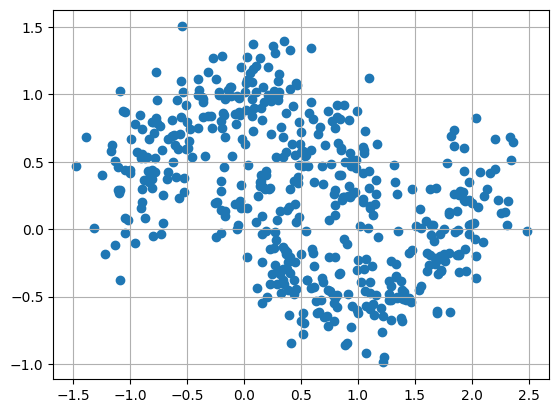

In [33]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], marker="o")
plt.grid(True)
plt.show()

In [2]:
"Voting"

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import VotingClassifier

voting_cls = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('sv', SVC()),
        ('rf', RandomForestClassifier())
    ])

voting_cls.fit(X_train, y_train)

print(voting_cls.score(X_test, y_test))

for name, cls in voting_cls.named_estimators_.items():
    print(name, "=", cls.score(X_test, y_test))

0.976
lr = 0.856
sv = 0.968
rf = 0.976


In [3]:
"Bagging and Pasting"

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagg = BaggingClassifier(
    DecisionTreeClassifier(
        splitter="random", # random treshold, Extra-Trees or Extremely Randomized Trees
        max_features="sqrt", # random subset of features
        max_leaf_nodes=16), 
    n_jobs=-1, 
    bootstrap=True, # False (no replacements) for Pasting 
    n_estimators=200, 
    max_samples=100, 
    random_state=42,
    oob_score=True)

bagg.fit(X_train, y_train)
print(bagg.oob_score_) # Only if oob_score=True

print(bagg.score(X_test, y_test))

from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, bagg.predict(X_test)))

0.96
0.976
0.976


In [4]:
"Random Forest"

rnd_clf = RandomForestClassifier(
    n_estimators=500, 
    n_jobs=-1, 
    random_state=42)

rnd_clf.fit(X_train, y_train)
rnd_clf.score(X_test, y_test)

0.976

In [5]:
rnd_clf.feature_importances_

array([0.42902984, 0.57097016])

In [16]:
"AdaBoost"

from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    learning_rate=0.5,
    random_state=42,
    # algorithm="SAMME" # The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
)
ada_clf.fit(X_train, y_train)

ada_clf.score(X_test, y_test)

0.976

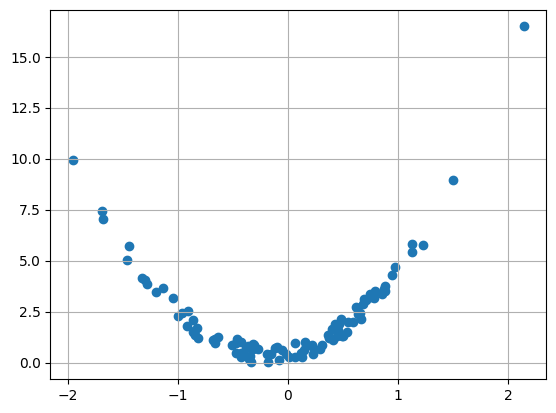

In [95]:
import numpy as np

m = 100 
rng = np.random.default_rng(seed=42)
X2_train = rng.standard_normal((m, 1))[:,0]
y2_train = 3* X2_train**2 + X2_train + rng.random(m)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(X2_train, y2_train, marker="o")
plt.grid(True)
plt.show()

1.0


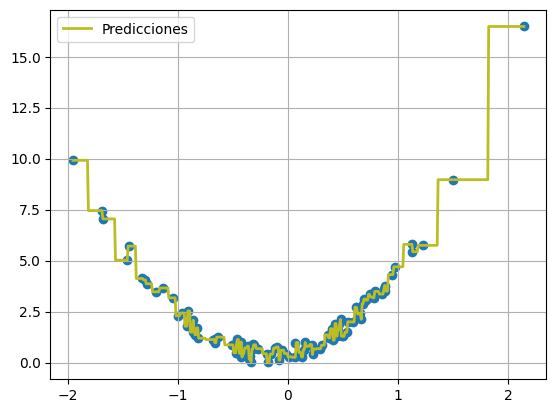

In [98]:
from sklearn.ensemble import GradientBoostingRegressor # it really is GBRT, the base predictor is a DecisionTree

gb_reg = GradientBoostingRegressor(max_depth=None, n_estimators=500, learning_rate=1.0, random_state=42)
gb_reg.fit(X2_train.reshape(-1, 1), y2_train)

X_new = np.linspace(X2_train.min(), X2_train.max(), 500).reshape(-1, 1)

y2_pred = gb_reg.predict(X_new)
print(gb_reg.score(X2_train.reshape(-1, 1), y2_train))

line = ax.plot(X_new, y2_pred, color="C8", linewidth=2, label="Predicciones")
ax.legend()
fig

In [108]:
"Stacking"

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

stacking_clf = StackingClassifier(
estimators=[
('lr', LogisticRegression(random_state=42)),
('rf', RandomForestClassifier(random_state=42)),
('svc', SVC(probability=True, random_state=42))
],
final_estimator=RandomForestClassifier(random_state=43),
cv=5 # number of cross-validation folds
)

stacking_clf.fit(X_train, y_train)
stacking_clf.score(X_train, y_train)

0.984